# End to End Customer Churn project notebook research

## dependencies

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score
)
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import optuna
import time

## data ingestion

In [2]:
data = pd.read_csv("../data/churn.csv")
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
pd.set_option("display.max_columns", None)

## basic data exploration

In [4]:
# check columns
data.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [5]:
# churn value counts
data["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [6]:
# data shape
data.shape

(7043, 21)

In [7]:
# missing values
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
# duplicates
data.duplicated().sum()

np.int64(0)

In [9]:
# dropping id
data = data.drop("customerID", axis=1)
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
data.shape

(7043, 20)

In [11]:
columns = data.columns.tolist()

In [12]:
# numerical features
num_features = data.select_dtypes(include="number")
num_features.columns.tolist()

['SeniorCitizen', 'tenure', 'MonthlyCharges']

In [13]:
# converting TotalCharges from str dtype to a numerical dtype (float64)
data["TotalCharges"] = (
    data["TotalCharges"]
    .str.strip()
    .pipe(pd.to_numeric, errors="coerce")
)

In [14]:
# cat features
cat_features  = data.select_dtypes(exclude="number")
cat_features.columns.tolist()

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [15]:
cat_features = data.select_dtypes(exclude="number")
cat_features

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,No
1,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,No
2,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,Yes
3,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),No
4,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,Yes,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,No
7039,Female,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),No
7040,Female,Yes,Yes,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
7041,Male,Yes,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,Yes


In [16]:
data["TotalCharges"].map(type).value_counts()

TotalCharges
<class 'float'>    7043
Name: count, dtype: int64

In [17]:
data = data.dropna()
data.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [18]:
data.shape

(7032, 20)

### Insights about the data
    - most columns are categorical features, and they should be encoded
    - no missing values nor duplicates exist in the dataset.
    - the labels are the "churn" what we are trying to predict
    - most categorical variables has 2, 3, or 4 categories
    - for those with 2 we will replace with 0 and 1
    - for those with 3 and 4 we do one-hot encoding

## Encoding

### binary encoding

In [19]:

yes_no_map = {"Yes": 1, "No": 0}
gender_map = {"Male": 1, "Female": 0}

data[[
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
    "Churn"
]] = data[[
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
    "Churn"
]].apply(lambda s: s.map(yes_no_map))

data["gender"] = data["gender"].map(gender_map)

In [20]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   int64  
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   int64  
 3   Dependents        7032 non-null   int64  
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   int64  
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   int64  
 16  PaymentMethod     7032 non-null   object 
 17  

### one-hot encoding

In [22]:
# multi category columns
multi_cat_cols = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod"
]

In [23]:
# encoding
data = pd.get_dummies(
    data,
    columns = multi_cat_cols,
    drop_first = True
)

In [24]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


In [25]:
data.shape

(7032, 31)

## cleaning

In [26]:
bool_cols = data.select_dtypes(include="bool").columns
data[bool_cols] = data[bool_cols].astype(int)

In [27]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   PaperlessBilling                       7032 non-null   int64  
 7   MonthlyCharges                         7032 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7032 non-null   int64  
 10  MultipleLines_No phone service         7032 non-null   int64  
 11  MultipleL

## correlation matrix

In [29]:
data.columns.tolist()

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'PaperlessBilling',
 'MonthlyCharges',
 'TotalCharges',
 'Churn',
 'MultipleLines_No phone service',
 'MultipleLines_Yes',
 'InternetService_Fiber optic',
 'InternetService_No',
 'OnlineSecurity_No internet service',
 'OnlineSecurity_Yes',
 'OnlineBackup_No internet service',
 'OnlineBackup_Yes',
 'DeviceProtection_No internet service',
 'DeviceProtection_Yes',
 'TechSupport_No internet service',
 'TechSupport_Yes',
 'StreamingTV_No internet service',
 'StreamingTV_Yes',
 'StreamingMovies_No internet service',
 'StreamingMovies_Yes',
 'Contract_One year',
 'Contract_Two year',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check']

In [30]:
corr = data.corr(numeric_only=True)
churn_corr = corr[["Churn"]].sort_values(
    by = "Churn",
    ascending = False
)
print(churn_corr)

                                          Churn
Churn                                  1.000000
InternetService_Fiber optic            0.307463
PaymentMethod_Electronic check         0.301455
MonthlyCharges                         0.192858
PaperlessBilling                       0.191454
SeniorCitizen                          0.150541
StreamingTV_Yes                        0.063254
StreamingMovies_Yes                    0.060860
MultipleLines_Yes                      0.040033
PhoneService                           0.011691
gender                                -0.008545
MultipleLines_No phone service        -0.011691
DeviceProtection_Yes                  -0.066193
OnlineBackup_Yes                      -0.082307
PaymentMethod_Mailed check            -0.090773
PaymentMethod_Credit card (automatic) -0.134687
Partner                               -0.149982
Dependents                            -0.163128
TechSupport_Yes                       -0.164716
OnlineSecurity_Yes                    -0

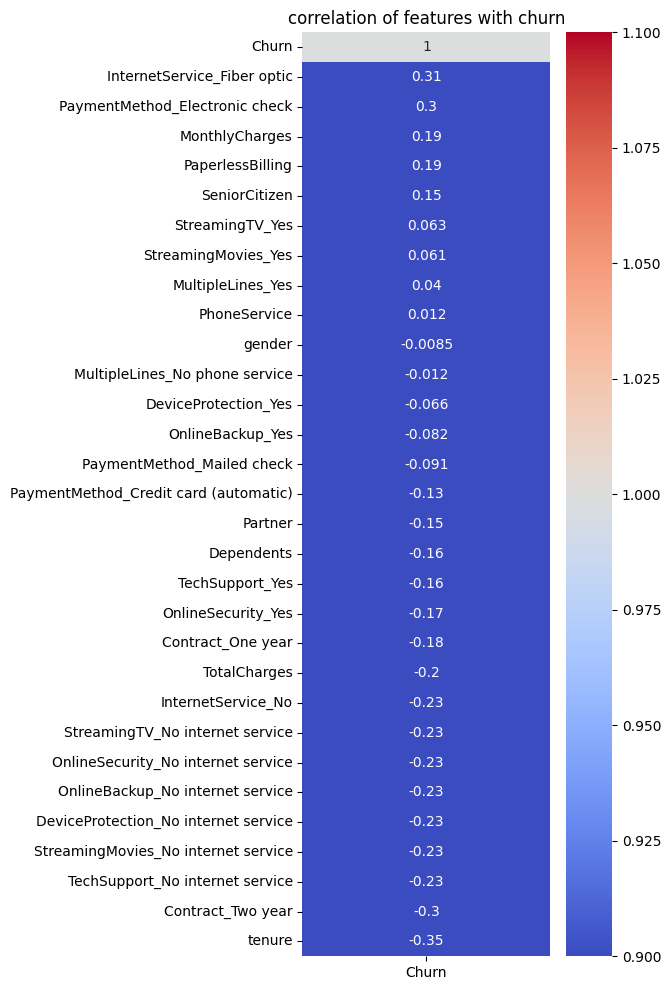

In [31]:


#correlation hetmap
plt.figure(figsize=(4, 12))
sns.heatmap(
    churn_corr,
    annot = True,
    cmap = "coolwarm",
    vmin = 1,
    vmax = 1
)
plt.title("correlation of features with churn")
plt.show()

### correlation report:
    - tenure (-0.35) --> customers who stay longer are less likely to churn
    - Contract_Two year (-0.30) --> customers on long term contracts churn much less
    - Contract_One year (-0.18) --> same trend but weaker than two year contracts
    - InternetService_Fibre optic (+0.31) --> fibre optic users churn more
    - PaymentMethod_Electronic check (+0.30) --> Customers paying electronically via check churn more.

## looking for multicolinearity (VIF)

In [32]:
# collapsing redundant cols efore running VIF
data.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1


In [33]:
data["No_internet_service"] = (
    data["OnlineSecurity_No internet service"] |
    data["OnlineBackup_No internet service"] |
    data["DeviceProtection_No internet service"] |
    data["TechSupport_No internet service"] |
    data["StreamingTV_No internet service"] |
    data["StreamingMovies_No internet service"]
).astype(int)

In [34]:
# dropping original redundant dummies
drop_cols = [column for column in data.columns if "No internet service" in column]
data = data.drop(columns=drop_cols)

In [35]:
data.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,No_internet_service
0,0,0,1,0,1,0,1,29.85,29.85,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0
2,1,0,0,0,2,1,1,53.85,108.15,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0


In [36]:
# handling phone service redundancy
if "MultipleLines_No phone service" in data.columns:
    data["No_phone_service"] = data["MultipleLines_No phone service"].astype(int)
    data = data.drop(columns=["MultipleLines_No phone service"])

In [37]:
data.shape

(7032, 26)

In [38]:
data.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,No_internet_service,No_phone_service
0,0,0,1,0,1,0,1,29.85,29.85,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1
1,1,0,0,0,34,1,0,56.95,1889.50,0,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0,0
2,1,0,0,0,2,1,1,53.85,108.15,1,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0


In [39]:
# preparing x
X = data.drop(columns=["Churn"])
bool_cols = X.select_dtypes(include="bool").columns
X[bool_cols] = X[bool_cols].astype(int)
X.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,No_internet_service,No_phone_service
0,0,0,1,0,1,0,1,29.85,29.85,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1
1,1,0,0,0,34,1,0,56.95,1889.50,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0,0
2,1,0,0,0,2,1,1,53.85,108.15,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0


In [40]:
# removing rows with missing or infinite values
X = X.where(~np.isinf(X), np.nan)
X = X.dropna()

In [41]:
# running vif
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i) for i in range(X.shape[1])
]
vif_data = vif_data.sort_values(
    by = "VIF",
    ascending = False
)
print(vif_data)

/home/kami/miniconda3/envs/std-prog/lib/python3.13/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                                  feature          VIF
11                     InternetService_No          inf
23                    No_internet_service          inf
5                            PhoneService  1773.528816
7                          MonthlyCharges   866.089640
10            InternetService_Fiber optic   148.500814
24                       No_phone_service    60.842267
17                    StreamingMovies_Yes    24.156394
16                        StreamingTV_Yes    24.080019
8                            TotalCharges    10.811490
4                                  tenure     7.584453
9                       MultipleLines_Yes     7.289761
14                   DeviceProtection_Yes     6.924754
13                       OnlineBackup_Yes     6.796678
15                        TechSupport_Yes     6.476508
12                     OnlineSecurity_Yes     6.338349
19                      Contract_Two year     2.652328
21         PaymentMethod_Electronic check     1.976032
22        

### multicollinearity report
    - as observed there is a multicolinearity between features
    - either we drop some features or use regularization techniques like Lasso or Ridge
    - or use tree based models which are less sensitive to multicollinearity
    - example in decision trees, splits are based on feature importance for reducing impurity --> redundant features just compete but wont cause unstable predictions.

## machine learning (training, evaluation)

In [42]:
data["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

### class imbalance 
    - given a 27% churners the labels are very imbalanced
    - for those numbers, class weighting + threshhold tuning would suffice

### metrics
    - recall and metrics derived from it such as F1 is most impotant
    - this is because business context prediction is assymetric in cost meaning missing churners (FN) usually costs more than wrngly targeting a loyal customer
    - if retention campaigns are cheap --> prioritze recall (catch every possible churner)
    - if retention campaign are expensive --> balance precision and recall using F1 score or a precision-recall trade-off.
    - if business wants a ranking of churn risk --> use ROC-AUC or PR-AUC to evaluate the model

In [43]:
# preparing data
X, y = data.drop(columns=["Churn"]), data["Churn"]
X.shape

(7032, 25)

In [44]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 21,
    stratify = y
)
print(X.shape, X_train.shape, X_test.shape)

(7032, 25) (5625, 25) (1407, 25)


In [45]:
# lower than 0.5 to boost recall
THRESHOLD = 0.3

### random forest classifier

In [46]:
# model initialization
rf_model = RandomForestClassifier(
    n_estimators = 300,
    class_weight = "balanced",
    random_state = 21,
    n_jobs = -1
)

In [47]:
# training
rf_model.fit(
    X_train,
    y_train
)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [48]:
# predictions
rf_proba = rf_model.predict_proba(X_test)[:, 1]
y_pred = (rf_proba >= THRESHOLD).astype(int)

clf_report = classification_report(
    y_test,
    y_pred,
    digits = 3
)
print("classification report:\n", clf_report)

classification report:
               precision    recall  f1-score   support

           0      0.878     0.747     0.808      1033
           1      0.506     0.714     0.592       374

    accuracy                          0.738      1407
   macro avg      0.692     0.731     0.700      1407
weighted avg      0.779     0.738     0.750      1407



### lightgbm classifier

In [49]:
# lightgbm classifier initialization
lgbm = LGBMClassifier(
    n_estimators = 500,
    learning_rate = 0.05,
    class_weight = "balanced",
    random_state = 21,
    n_jobs = -1
)

In [50]:
# training with timer
start_train = time.time()
lgbm.fit(
    X_train,
    y_train
)
train_time = time.time() - start_train
print(f"training time: {train_time:.2f} seconds")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4130
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.043661 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 627
[LightGBM] [Info] Number of data points in the train set: 5625, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
training time: 23.14 seconds


In [51]:
# prediction with timer
start_pred = time.time()
lgbm_proba = lgbm.predict_proba(X_test)[:, 1]
lgbm_pred = (lgbm_proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print (f"prediction time: {pred_time:.4f} seconds")

lgbm_clf_report = classification_report(
    y_test,
    lgbm_pred,
    digits = 3
)

print("classification report:\n", lgbm_clf_report)

prediction time: 0.0607 seconds
classification report:
               precision    recall  f1-score   support

           0      0.901     0.672     0.770      1033
           1      0.468     0.797     0.590       374

    accuracy                          0.705      1407
   macro avg      0.685     0.734     0.680      1407
weighted avg      0.786     0.705     0.722      1407



##

In [52]:
# thresholfd tuning 
print("threshold tuning...............\n")
print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")

thresholds = [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
for threshold in thresholds:
    preds = (lgbm_proba >= threshold).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{threshold:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

threshold tuning...............

Thresh  Prec_1  Rec_1   F1_1    
0.25    0.452   0.821   0.583   
0.3     0.468   0.797   0.590   
0.35    0.481   0.762   0.590   
0.4     0.494   0.719   0.585   
0.45    0.512   0.687   0.587   
0.5     0.539   0.660   0.594   


### xgboost classifier

In [53]:
# calculating the scale pos weight for imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

In [54]:
# xgbclassifier initialization
xgb = XGBClassifier(
    n_estimators = 500,
    learning_rate = 0.05,
    max_depth = 6,
    subsample = 0.8,
    colsample_bytree = 0.8,
    random_state = 21,
    n_jobs = -1,
    scale_pos_weight = scale_pos_weight,
    eval_metric = "logloss"
)

In [55]:
# xgb classifier training
start_train = time.time()
xgb.fit(
    X_train,
    y_train
)
train_time = time.time() - start_train
print(f"training time: {train_time:.4f} seconds")

training time: 3.0367 seconds


In [56]:
# predictions
start_pred = time.time()
xgb_proba = xgb.predict_proba(X_test)[:, 1]
y_pred = (xgb_proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f"⏱ prediction time: {pred_time:.4f} seconds")

clf_report = classification_report(
    y_test,
    y_pred,
    digits = 3
)
print("classification report:\n", clf_report)

⏱ prediction time: 0.0994 seconds
classification report:
               precision    recall  f1-score   support

           0      0.908     0.671     0.772      1033
           1      0.472     0.813     0.597       374

    accuracy                          0.709      1407
   macro avg      0.690     0.742     0.684      1407
weighted avg      0.792     0.709     0.725      1407



In [57]:
# threshhold tuning for xgboost
thresholds = [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

print("threshold tuning for XGBoost")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for threshold in thresholds:
    preds = (xgb_proba >= threshold).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{threshold:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

threshold tuning for XGBoost
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.451   0.837   0.586   
0.3     0.472   0.813   0.597   
0.35    0.484   0.775   0.596   
0.4     0.493   0.722   0.586   
0.45    0.512   0.690   0.588   
0.5     0.526   0.655   0.583   


### model's choice:
    - xgboost's classifier
    - gives a decent  recall (same as lightGBM) but much faster to train

## hyperparameter tuning (optuna) & experiment tracking with MLFLOW

In [59]:
# objective function for optuna
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "random_state": 21,
        "n_jobs": -1,
        "scale_pos_weight": (y_train == 0).sum() / (y_train == 1).sum(),
        "eval_metric": "logloss"
    }

    model = XGBClassifier(**params)
    model.fit(
        X_train,
        y_train
    )
    proba = model.predict_proba(X_test)[:, 1]
    y_pred = (proba >= THRESHOLD).astype(int)
    rec_score = recall_score(
        y_test,
        y_pred,
        pos_label = 1
    )
    
    return rec_score